# 21_因果推断基础-逆概率加权与重叠问题

## Notebook 使用说明

建议先阅读《05. 倾向评分与协变量平衡》。本篇需要 NumPy、pandas、Matplotlib 和 statsmodels。缺少依赖时，可在当前 Python 环境安装：`python -m pip install numpy pandas matplotlib statsmodels`。

本篇主要依据参考资料 [1] 第 11.2–11.3、20.1 节与 [2] 第 5.3 节。沿用上一份的主模拟，再另设一个可以直接计算修剪后目标的例子。汇总表和模拟数据都是教学构造，不是原书的实证结果。有效样本量、评分截断后的总体极限和稳定化权重对照属于本篇的计算补充，会分别说明。

数据和图形均由代码生成，不需要外部文件，也不依赖前面 Notebook 的变量或 `notebook_support.py`。主分析仍采用独立同分布抽样的总体视角。Bootstrap 重抽整行观察数据，并重新拟合评分；重复模拟则重新生成研究对象，不使用固定有限总体的随机化方差公式。

代码输出和图形均保存在 Notebook 中。重新运行请使用 Restart Kernel and Run All Cells；下文解释对应默认参数，修改参数后以新的输出为准。

In [1]:
# 环境初始化：本篇不读取外部数据，单独放在一个文件夹中也可以运行。
import os
import sys
import tempfile
import warnings
from pathlib import Path
from statistics import NormalDist

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib")
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display
import statsmodels
import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import PerfectSeparationWarning

%matplotlib inline

_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [
    f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei",
                "SimHei", "Noto Sans CJK SC", "Noto Sans CJK JP"]
    if f in _available_fonts
] + ["DejaVu Sans"]
plt.rcParams.update({
    "font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
    "figure.dpi": 100, "figure.max_open_warning": 30,
})
pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 140)

SEED_DATA = 42
SEED_BOOT = 2026
SEED_OVERLAP = 2027
SEED_REPEAT = 2028
N_MAIN = 3000
N_BOOT = 999
N_OVERLAP = 1500
N_REPEATS = 500
STRENGTHS = (0.5, 1.5, 3.0)
TRIM_ALPHA = 0.10
ALPHA = 0.05
Z_CRIT = NormalDist().inv_cdf(1-ALPHA/2)

print(f"Python {sys.version.split()[0]}")
print(f"NumPy {np.__version__} | pandas {pd.__version__} | Matplotlib {plt.matplotlib.__version__}")
print(f"statsmodels {statsmodels.__version__}")

Python 3.13.5
NumPy 2.3.5 | pandas 2.2.3 | Matplotlib 3.10.8
statsmodels 0.14.6


上一篇把评分相近的人放在同一层，再比较层内两组。这里不再划分五层、十层，而是给每个人一个权重。

比如，一类人中只有五分之一接受处理，那么观察到的一位接受者，要代表多少同类人？用 $1/0.2=5$ 加权，是一个自然的想法。但到了实际数据中，有人的处理概率可能只有 0.01，一位接受者就会带上 100 的权重。这个人的结局稍有变化，最后的估计也可能跟着大幅变化。

下面先把权重为什么这样算讲清楚，再比较两种求平均的方法。最后改变重叠程度，看看限制权重和删去低重叠样本分别改变了什么。

## 理论基础

### 1. 为什么用概率的倒数？

仍用 $T\in\{0,1\}$ 表示处理，$X$ 表示选定的处理前变量，$Y$ 表示结局，$e(X)=P(T=1\mid X)$。目标为总体平均处理效应：

$$
\tau=E[Y(1)-Y(0)].
$$

在处理定义清楚、无干扰、满足一致性、条件可忽略性和重叠的前提下，

$$
E\!\left[\frac{TY}{e(X)}\right]=E[Y(1)],\qquad
E\!\left[\frac{(1-T)Y}{1-e(X)}\right]=E[Y(0)].
$$

所以，虽然每个人只观察到一个结局，仍可以用两种加权平均恢复两种潜在结局的总体均值。[1，定理 11.2；2，定理 5.3.1]

只看处理组的一项。根据一致性，有 $TY=TY(1)$；再用条件可忽略性拆开条件期望：

$$
\begin{aligned}
E\!\left[\frac{TY}{e(X)}\mid X\right]
&=\frac{E[T\mid X]E[Y(1)\mid X]}{e(X)}\\
&=\frac{e(X)E[Y(1)\mid X]}{e(X)}
=E[Y(1)\mid X].
\end{aligned}
$$

分配机制少给了某一类人多少处理机会，倒数权重就在平均时补回相应比例。这里“代表五个人”是对加权贡献的解释，不是真的新增了四位独立受试者。

两组要用不同的分母：处理组用 $1/e(X)$，对照组用 $1/\{1-e(X)\}$。一个评分接近 1 的人，如果实际未接受处理，才会带上很大的对照权重。

### 2. HT 与 Hájek：加权之后除以什么？

将未知评分换成估计值 $\widehat e_i$。记

$$
w_{1i}=\frac{T_i}{\widehat e_i},\qquad
w_{0i}=\frac{1-T_i}{1-\widehat e_i}.
$$

Horvitz–Thompson（HT）估计把两组加权总和分别除以全体人数 $n$：

$$
\widehat\tau_{\mathrm{HT}}
=\frac{\sum_i w_{1i}Y_i}{n}-\frac{\sum_i w_{0i}Y_i}{n}.
$$

Hájek 估计则分别除以各组的权重和：

$$
\widehat\tau_{\mathrm{H}}
=\frac{\sum_i w_{1i}Y_i}{\sum_i w_{1i}}
-\frac{\sum_i w_{0i}Y_i}{\sum_i w_{0i}}.
$$

两者都属于逆概率加权（Inverse Probability Weighting，IPW）。真实评分下，$E[T/e(X)]=E[(1-T)/(1-e(X))]=1$，但一次样本里的两组权重和不一定都等于 $n$，因此两个估计通常不同。[1，第 11.2.2 节]

使用真实评分时，HT 的无偏性来自上面的期望恒等式；换成估计评分后，不能直接声称有限样本仍无偏。Hájek 是比值估计，也不普遍有限样本无偏。在合适的评分模型、重叠与矩条件下，两者可以估计同一总体目标。下面会把单次结果与重复模拟分开看。

## 完整案例一：权重怎样重新组织比较？

### 1. 从三层汇总表开始

设全体 400 人分为三层。各层的处理比例不同，结局均值也不同。为了让每一步能手算，直接使用层内处理比例 $\widehat e_k=n_{k1}/n_k$ 作为评分；这相当于对离散层拟合饱和的处理模型，不是把它当成已知的真实分配概率。

这张表仅用于演示计算。它没有证明层内不存在未测混杂；只有识别假设也成立时，后面的标准化差值才有相应的因果解释。

In [2]:
toy = pd.DataFrame({
    "层": ["低", "中", "高"], "n": [100, 200, 100],
    "n1": [20, 100, 80], "Y均值1": [12.0, 18.0, 23.0],
    "Y均值0": [10.0, 14.0, 20.0],
}).set_index("层")
toy["n0"] = toy["n"]-toy["n1"]
toy["e_hat"] = toy["n1"]/toy["n"]
toy["处理组权重"] = 1/toy["e_hat"]
toy["对照组权重"] = 1/(1-toy["e_hat"])
toy["加权人数1"] = toy["n1"]*toy["处理组权重"]
toy["加权人数0"] = toy["n0"]*toy["对照组权重"]
display(toy[["n", "n1", "n0", "e_hat", "处理组权重", "对照组权重",
             "加权人数1", "加权人数0"]].round(3))

,n,n1,n0,e_hat,处理组权重,对照组权重,加权人数1,加权人数0
层,,,,,,,,
低,100,20,80,0.2,5.00,1.25,100.0,100.0
中,200,100,100,0.5,2.00,2.00,200.0,200.0
高,100,80,20,0.8,1.25,5.00,100.0,100.0


第一层 20 位接受者各带权重 5，合起来是 100；80 位未接受者各带权重 1.25，合起来也是 100。其他层同理。于是两组的加权层比例都变成全体人群的 0.25、0.50、0.25。

这一次，HT、Hájek 与第四篇的直接标准化恰好相等。原因不是三种方法永远一样，而是这里采用了离散层内的经验评分，且每层两组都存在。下面把这个等式直接核对。[1，习题 12.1 中关于分层、HT、Hájek 的部分]

,估计
原始均值差,6.40
直接标准化,3.25
HT,3.25
Hájek,3.25


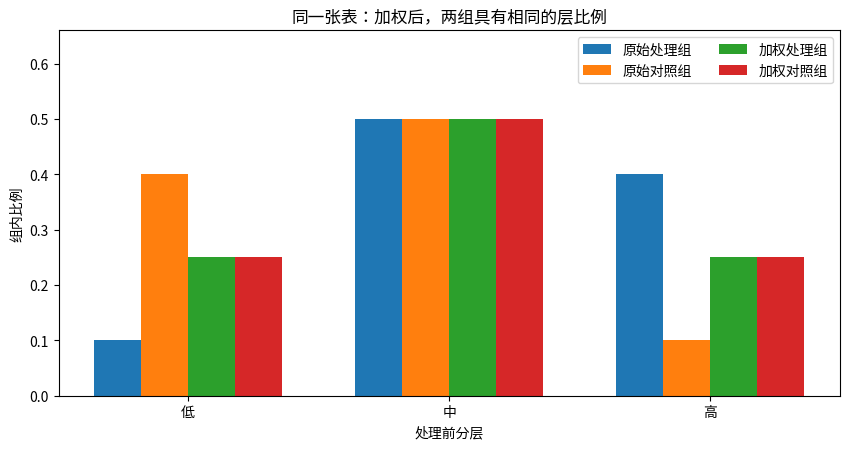

In [3]:
toy_n = toy["n"].sum()
toy_raw = (np.average(toy["Y均值1"], weights=toy["n1"])
           - np.average(toy["Y均值0"], weights=toy["n0"]))
toy_ht = ((toy["加权人数1"]*toy["Y均值1"]).sum()
          - (toy["加权人数0"]*toy["Y均值0"]).sum())/toy_n
toy_hajek = (np.average(toy["Y均值1"], weights=toy["加权人数1"])
             - np.average(toy["Y均值0"], weights=toy["加权人数0"]))
toy_standardized = np.average(toy["Y均值1"]-toy["Y均值0"], weights=toy["n"])
display(pd.Series({"原始均值差": toy_raw, "直接标准化": toy_standardized,
                   "HT": toy_ht, "Hájek": toy_hajek}, name="估计").to_frame().round(4))
np.testing.assert_allclose([toy_ht, toy_hajek], toy_standardized, atol=1e-12)

fig, ax = plt.subplots(figsize=(8.6, 4.6))
positions = np.arange(len(toy))
for offset, label, values in [
    (-0.27, "原始处理组", toy["n1"]/toy["n1"].sum()),
    (-0.09, "原始对照组", toy["n0"]/toy["n0"].sum()),
    (0.09, "加权处理组", toy["加权人数1"]/toy["加权人数1"].sum()),
    (0.27, "加权对照组", toy["加权人数0"]/toy["加权人数0"].sum()),
]:
    ax.bar(positions+offset, values, width=0.18, label=label)
ax.set_xticks(positions, toy.index)
ax.set(xlabel="处理前分层", ylabel="组内比例", ylim=(0, 0.66),
       title="同一张表：加权后，两组具有相同的层比例")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

## 完整案例二：用估计评分进行加权

### 1. 保留上一份的生成机制

这次仍用第五篇的三个处理前变量，避免换了数据后难以比较。各个随机项相互独立，具体规则为：

$$
\begin{aligned}
X_1,X_2&\sim\operatorname{Uniform}(-1,1),\quad X_3\sim\operatorname{Bernoulli}(0.5),\\
\eta(X)&=-0.4+X_1-0.5X_2+0.6X_3+1.8(X_1^2-1/3)+1.2X_1X_2,\\
e(X)&=\operatorname{expit}\{\eta(X)\},\quad T\mid X\sim\operatorname{Bernoulli}\{e(X)\},\\
\mu_0(X)&=10+2X_1+1.5X_2+2X_3+6X_1^2+3X_1X_2,\\
\tau(X)&=2+0.5X_1+0.8X_3,\\
Y(0)&=\mu_0(X)+\varepsilon,\quad Y(1)=Y(0)+\tau(X),\quad\varepsilon\sim N(0,1).
\end{aligned}
$$

总体 ATE 仍为 2.4。先生成 $X,T$、结局与真值，并分开保存。评分拟合和权重诊断只使用 $X,T$；真值不进入估计函数。

In [4]:
def expit(value):
    """稳定计算 Logistic 概率。"""
    return np.exp(-np.logaddexp(0.0, -np.asarray(value, dtype=float)))


def make_observational_data(n: int, seed: int):
    if isinstance(n, bool) or not isinstance(n, (int, np.integer)) or n < 20:
        raise ValueError("n 必须是至少为 20 的整数。")
    rng = np.random.default_rng(seed)
    x1, x2 = rng.uniform(-1, 1, n), rng.uniform(-1, 1, n)
    x3 = rng.binomial(1, 0.5, n)
    eta = -0.4+x1-0.5*x2+0.6*x3+1.8*(x1**2-1/3)+1.2*x1*x2
    p = expit(eta)
    t = rng.binomial(1, p)
    mu0 = 10+2*x1+1.5*x2+2*x3+6*x1**2+3*x1*x2
    tau = 2+0.5*x1+0.8*x3
    y0 = mu0+rng.normal(0, 1, n)
    y1 = y0+tau
    design = pd.DataFrame({"X1": x1, "X2": x2, "X3": x3, "T": t})
    return design, np.where(t == 1, y1, y0), {
        "propensity": p, "y0": y0, "y1": y1, "tau": tau, "population_ate": 2.4,
    }


design, outcome, truth = make_observational_data(N_MAIN, SEED_DATA)
t = design["T"].to_numpy()
display(design.head(8).round(4))
display(design.groupby("T").agg(n=("T", "size"), X1均值=("X1", "mean"),
                               X2均值=("X2", "mean"), X3比例=("X3", "mean")).round(4))

,X1,X2,X3,T
0,0.5479,0.6584,0,0
1,-0.1222,0.1882,0,0
2,0.7172,-0.5103,1,1
3,0.3947,0.4914,0,0
4,-0.8116,-0.8310,0,1
5,0.9512,0.5488,0,1
6,0.5223,0.1800,1,1
7,0.5721,-0.7785,1,1


,n,X1均值,X2均值,X3比例
T,,,,
0,1565,-0.1398,0.0456,0.4441
1,1435,0.1505,-0.0917,0.5756


### 2. 先拟合处理概率

仍比较两个事先指定的模型：仅主效应，以及主效应加 $X_1^2,X_1X_2$。后者能表达本例的真实分配规则，但拟合时不会直接使用生成机制的系数。

下面保留概率预测，不把它转成 0/1 分类。完全分离、未收敛或数值端点都应先检查，不能在程序深处悄悄用一个很小的数替换。评分截断会在后面的专门实验里明确执行。[1，第 11.2.2–11.2.3 节]

In [5]:
def ps_matrix(data, specification="rich"):
    x1, x2, x3 = (data[name].to_numpy(dtype=float) for name in ("X1", "X2", "X3"))
    columns = [np.ones(len(data)), x1, x2, x3]
    if specification == "rich":
        columns += [x1**2, x1*x2]
    elif specification != "main":
        raise ValueError("specification 只能是 main 或 rich。")
    return np.column_stack(columns)


def fit_logistic(matrix, treatment):
    """无惩罚二项 GLM；异常不以静默截断评分的方式掩盖。"""
    A, z = np.asarray(matrix, dtype=float), np.asarray(treatment, dtype=float)
    if A.ndim != 2 or z.ndim != 1 or len(A) != len(z):
        raise ValueError("设计矩阵应为二维，处理应为等长的一维向量。")
    if not np.isfinite(A).all() or not np.isfinite(z).all():
        raise ValueError("输入不能包含非有限值。")
    if not np.isin(z, [0, 1]).all() or np.unique(z).size != 2:
        raise ValueError("处理必须为 0/1，并且两组都存在。")
    if np.linalg.matrix_rank(A) < A.shape[1]:
        raise ValueError("设计矩阵列不满秩。")
    with warnings.catch_warnings():
        warnings.simplefilter("error", PerfectSeparationWarning)
        result = sm.GLM(z, A, family=sm.families.Binomial()).fit(maxiter=100, tol=1e-10)
    if not result.converged or not np.isfinite(result.params).all():
        raise RuntimeError("Logistic 模型未正常收敛。")
    return result


MODEL_NAMES = {"main": "仅主效应", "rich": "含二次与交互"}
matrices, fits, scores = {}, {}, {}
for specification in MODEL_NAMES:
    matrices[specification] = ps_matrix(design, specification)
    fits[specification] = fit_logistic(matrices[specification], t)
    scores[specification] = np.asarray(fits[specification].predict(matrices[specification]))
display(pd.DataFrame({MODEL_NAMES[s]: np.quantile(scores[s], [0, .01, .5, .99, 1])
                      for s in scores}, index=["最小", "1%", "中位数", "99%", "最大"]).round(4))

,仅主效应,含二次与交互
最小,0.1401,0.1017
1%,0.1722,0.1259
中位数,0.4728,0.4335
99%,0.8000,0.9338
最大,0.8319,0.9669


### 3. 评分分布与实际权重

先看评分有没有把两组分到几乎不相交的区域，再看真正出现的权重。下面的直方图共用分箱，各组按自身人数归一化。

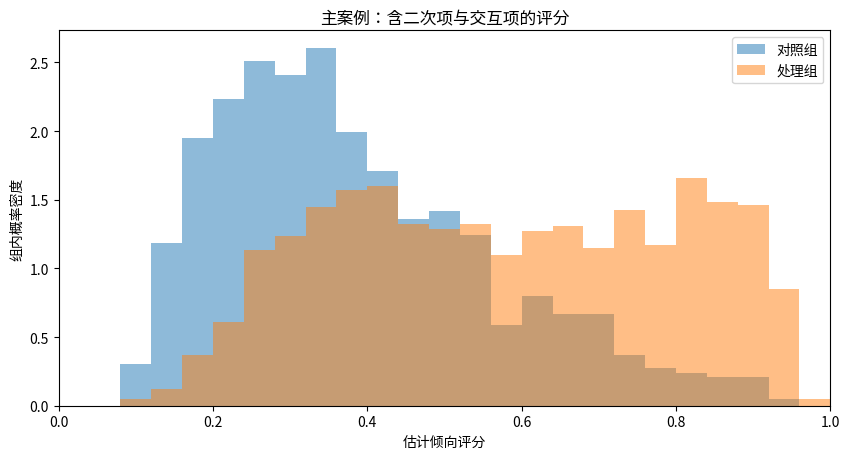

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 4.7))
bins = np.linspace(0, 1, 26)
for group, label in [(0, "对照组"), (1, "处理组")]:
    ax.hist(scores["rich"][t == group], bins=bins, density=True, alpha=0.5, label=label)
ax.set(xlabel="估计倾向评分", ylabel="组内概率密度", xlim=(0, 1),
       title="主案例：含二次项与交互项的评分")
ax.legend()
fig.tight_layout()
plt.show()

权重和变大，不代表独立信息变多。本篇增加两个便于读图的集中程度指标：组内最大归一化权重，以及每组的有效样本量（ESS）：

$$
\mathrm{ESS}_t=
\frac{\left(\sum_{i:T_i=t}w_i\right)^2}{\sum_{i:T_i=t}w_i^2}
=\frac{1}{\sum_{i:T_i=t}a_i^2},\qquad
 a_i=\frac{w_i}{\sum_{j:T_j=t}w_j}.
$$

这是本篇的诊断补充，不是原书给出的 IPW 标准误公式。把权重暂视为固定，若参与平均的变量相互独立且方差同为 $\sigma^2$，其加权均值方差为 $\sigma^2\sum_i a_i^2=\sigma^2/\mathrm{ESS}$，于是有了这个等效人数的解释。实际因果分析里的权重由数据估计，结局也可能异方差，因此 ESS 不能替代效应的标准误。

等权时 ESS 等于组内人数；一个人占据大部分权重时，ESS 会明显变小。所有权重同乘一个正常数，ESS 不变。

In [7]:
def ipw_weights(treatment, probability):
    """返回两个组的权重向量；非本组位置为 0，不自动截断概率。"""
    z, p = np.asarray(treatment, dtype=float), np.asarray(probability, dtype=float)
    if z.ndim != 1 or z.size == 0 or p.shape != z.shape:
        raise ValueError("处理与评分应为非空、等长的一维向量。")
    if not np.isfinite(z).all() or not np.isin(z, [0, 1]).all() or np.unique(z).size != 2:
        raise ValueError("处理只能为 0/1，且必须包含两组。")
    if not np.isfinite(p).all() or np.any((p <= 0) | (p >= 1)):
        raise ValueError("评分必须严格位于 (0,1)；先检查端点与重叠。")
    w1, w0 = z/p, (1-z)/(1-p)
    if not np.isfinite(w1).all() or not np.isfinite(w0).all():
        raise ValueError("权重不是有限数。")
    return w1, w0


def effective_sample_size(weights):
    w = np.asarray(weights, dtype=float)
    if w.ndim != 1 or w.size == 0 or not np.isfinite(w).all() or np.any(w < 0) or w.max() <= 0:
        raise ValueError("权重须为非负有限向量，且至少有一个正值。")
    scaled = w/w.max()  # ESS 不受共同缩放影响，也避免不必要的平方溢出。
    return float(scaled.sum()**2/np.dot(scaled, scaled))


def weight_diagnostics(treatment, probability):
    z = np.asarray(treatment)
    w1, w0 = ipw_weights(z, probability)
    rows = []
    for group, wg in [(0, w0[z == 0]), (1, w1[z == 1])]:
        rows.append({"组": group, "原始人数": len(wg), "权重和": wg.sum(),
                     "权重和/n": wg.sum()/len(z), "最大权重": wg.max(),
                     "ESS": effective_sample_size(wg), "最大组内份额": (wg/wg.sum()).max()})
    return pd.DataFrame(rows).set_index("组")


weight_tables = {label: weight_diagnostics(t, scores[s]) for s, label in MODEL_NAMES.items()}
display(pd.concat(weight_tables, names=["评分模型"]).round(4))

原始人数        权重和   权重和/n     最大权重        ESS  最大组内份额
评分模型   组                                                     
仅主效应   0  1565  2989.6765  0.9966   5.2974  1404.7180  0.0018
       1  1435  3007.4174  1.0025   6.2741  1258.8834  0.0021
含二次与交互 0  1565  3011.9431  1.0040  23.8191  1045.1465  0.0079
       1  1435  2980.8872  0.9936   9.3621  1134.8759  0.0031

### 4. 加权后的平衡，还要重新检查

上一张表里，含二次与交互的模型有更大的最大权重，ESS 也更小。这并不说明仅主效应模型更合适：错误模型也可能产生很温和的权重。还得看它实际平衡了什么。

这里继续使用第五篇的标准化均值差，但把分层标准化换成组内加权平均。对每个待检查变量 $h(X)$，

$$
\mathrm{SMD}_{w}(h)=
\frac{\overline h_{1,w}-\overline h_{0,w}}
{\sqrt{(s_{h,1}^2+s_{h,0}^2)/2}}.
$$

分母固定为原始两组样本方差的合并尺度，加权前后保持不变；平方项和交互项也要检查。它延续原书把 $h(X)$ 当作伪结局的思路，不过 SMD 和下方参考线是本篇的展示约定。参考线 0.1 只帮助看图，不是检验“没有混杂”的临界值。[1，第 11.3 节]

,不调整,仅主效应,含二次与交互
X1,0.5136,-0.0048,-0.0003
X2,-0.2415,-0.0139,-0.0212
X3,0.2653,0.0082,-0.0060
X1平方,0.5846,0.6139,-0.0023
X1×X2,0.2766,0.3392,0.0092


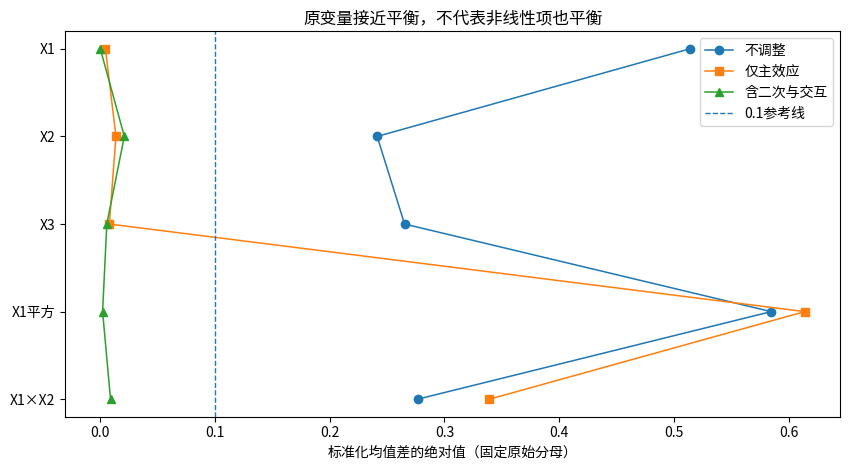

In [8]:
def balance_table(features, treatment, probability):
    X = np.asarray(features, dtype=float)
    z = np.asarray(treatment)
    w1, w0 = ipw_weights(z, probability)
    if X.ndim != 2 or len(X) != len(z) or not np.isfinite(X).all():
        raise ValueError("待检查特征应为与处理等长的有限二维矩阵。")
    if min(np.sum(z == 0), np.sum(z == 1)) < 2:
        raise ValueError("每组至少两人，才能计算原始方差。")
    scale = np.sqrt((X[z == 1].var(axis=0, ddof=1)+X[z == 0].var(axis=0, ddof=1))/2)
    if np.any(scale <= 0):
        raise ValueError("某列原始合并方差为零，不能报告该列 SMD。")
    raw = X[z == 1].mean(axis=0)-X[z == 0].mean(axis=0)
    weighted = np.average(X, weights=w1, axis=0)-np.average(X, weights=w0, axis=0)
    names = features.columns if isinstance(features, pd.DataFrame) else np.arange(X.shape[1])
    return pd.DataFrame({"原始SMD": raw/scale, "加权SMD": weighted/scale}, index=names)


features = design[["X1", "X2", "X3"]].copy()
features["X1平方"] = features["X1"]**2
features["X1×X2"] = features["X1"]*features["X2"]
balance = {s: balance_table(features, t, scores[s]) for s in MODEL_NAMES}
balance_comparison = pd.DataFrame({"不调整": balance["rich"]["原始SMD"],
                                   **{MODEL_NAMES[s]: balance[s]["加权SMD"] for s in MODEL_NAMES}})
display(balance_comparison.round(4))

fig, ax = plt.subplots(figsize=(8.6, 4.8))
for label, marker in zip(balance_comparison, ("o", "s", "^")):
    ax.plot(balance_comparison[label].abs(), np.arange(len(features.columns)),
            marker=marker, label=label, linewidth=1.1)
ax.axvline(0.1, linestyle="--", linewidth=1, label="0.1参考线")
ax.set_yticks(np.arange(len(features.columns)), features.columns)
ax.invert_yaxis()
ax.set(xlabel="标准化均值差的绝对值（固定原始分母）", title="原变量接近平衡，不代表非线性项也平衡")
ax.legend()
fig.tight_layout()
plt.show()

### 5. 最后再把观察结局放进计算

默认数据中，仅主效应加权后，三个原变量的差已很小，但平方项的绝对 SMD 仍约为 0.614、交互项约为 0.339。含二次与交互的模型把本次检查的五项差异都降到了约 0.022 以内。这比只比较最大权重，更能说明两个模型的区别。

模型和诊断项已经确定，现在计算效应。`w1` 与 `w0` 分别负责一种潜在均值，不要先把它们相减，再拿这个有正有负的向量调用普通加权平均。

下面保留 HT 的两个分量、Hájek 的两个分量，并列出几个人的原始结局与权重。真实评分只作模拟参照；实际研究里并没有这一列“答案”。

In [9]:
def ipw_estimate(treatment, outcome_values, probability):
    w1, w0 = ipw_weights(treatment, probability)
    y = np.asarray(outcome_values, dtype=float)
    if y.ndim != 1 or y.shape != w1.shape or not np.isfinite(y).all():
        raise ValueError("结局必须是等长、有限的一维向量。")
    mu1_ht, mu0_ht = np.dot(w1, y)/len(y), np.dot(w0, y)/len(y)
    mu1_h, mu0_h = np.dot(w1, y)/w1.sum(), np.dot(w0, y)/w0.sum()
    return {"mu1_HT": mu1_ht, "mu0_HT": mu0_ht, "HT": mu1_ht-mu0_ht,
            "mu1_H": mu1_h, "mu0_H": mu0_h, "Hájek": mu1_h-mu0_h}


y = outcome.copy()
w1, w0 = ipw_weights(t, scores["rich"])
row_check = design.copy()
row_check["Y"], row_check["e_hat"] = y, scores["rich"]
row_check["w1"], row_check["w0"] = w1, w0
row_check["w1Y"], row_check["w0Y"] = w1*y, w0*y
display(row_check.head(8).round(4))

estimates = {label: ipw_estimate(t, y, scores[s]) for s, label in MODEL_NAMES.items()}
estimates["真实评分（模拟参考）"] = ipw_estimate(t, y, truth["propensity"])
effect_table = pd.DataFrame(estimates).T
display(effect_table.round(4))
print(f"原始均值差：{y[t == 1].mean()-y[t == 0].mean():.4f}")
print(f"总体 ATE：{truth['population_ate']:.4f}")

,X1,X2,X3,T,Y,e_hat,w1,w0,w1Y,w0Y
0,0.5479,0.6584,0,0,15.2457,0.5517,0.0000,2.2309,0.0000,34.0115
1,-0.1222,0.1882,0,0,8.8469,0.2053,0.0000,1.2584,0.0000,11.1331
2,0.7172,-0.5103,1,1,17.4108,0.7778,1.2858,0.0000,22.3861,0.0000
3,0.3947,0.4914,0,0,12.4052,0.4063,0.0000,1.6843,0.0000,20.8944
4,-0.8116,-0.8310,0,1,13.7145,0.6332,1.5794,0.0000,21.6603,0.0000
5,0.9512,0.5488,0,1,22.2322,0.9000,1.1111,0.0000,24.7027,0.0000
6,0.5223,0.1800,1,1,15.7263,0.6658,1.5019,0.0000,23.6197,0.0000
7,0.5721,-0.7785,1,1,15.3749,0.6746,1.4823,0.0000,22.7909,0.0000


,mu1_HT,mu0_HT,HT,mu1_H,mu0_H,Hájek
仅主效应,16.1497,12.2352,3.9144,16.1098,12.2775,3.8323
含二次与交互,15.3694,13.0839,2.2854,15.4679,13.0321,2.4359
真实评分（模拟参考）,15.2173,12.6544,2.5630,15.5714,12.8584,2.7129


原始均值差：4.4944
总体 ATE：2.4000


原始均值差约为 4.494；仅主效应的 Hájek 估计约为 3.832，含二次与交互的 Hájek 约为 2.436。后者对应的 HT 却是 2.285，差别来自两组权重和没有恰好等于全体人数。

仅主效应模型留下的非线性不平衡，现在会进入效应估计。归一化只改变如何求平均，没有补上评分模型遗漏的关系。真实评分的单次结果也没有恰好等于 2.4；它不承担“每次最接近真值”的保证。

### 6. 给所有结局加 100，结果会变吗？

这是 Ding 第 11.2.2 节专门指出的差别。设 $\widehat 1_1=\sum_iw_{1i}/n$、$\widehat 1_0=\sum_iw_{0i}/n$。将所有 $Y_i$ 改为 $Y_i+c$，

$$
\widehat\tau_{\mathrm{HT}}(Y+c)
=\widehat\tau_{\mathrm{HT}}(Y)+c(\widehat 1_1-\widehat 1_0),\qquad
\widehat\tau_{\mathrm{H}}(Y+c)=\widehat\tau_{\mathrm{H}}(Y).
$$

真实的因果差值不会因计分起点改变。HT 在有限样本中却可能受影响，Hájek 的两组归一化消除了这一点。它解决的是位置平移问题，不是所有偏差或极端权重问题。[1，命题 11.1、习题 11.3]

,HT,Hájek,由恒等式算出的HT
共同平移c,,,
-100.0,3.32063,2.43586,3.32063
0.0,2.28543,2.43586,2.28543
100.0,1.25023,2.43586,1.25023


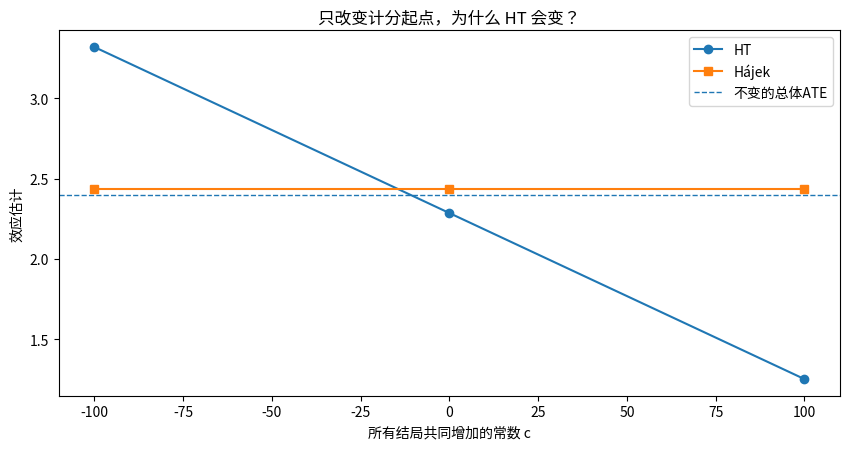

In [10]:
shifts = np.array([-100.0, 0.0, 100.0])
base = ipw_estimate(t, y, scores["rich"])
shift_rows = []
for c in shifts:
    result = ipw_estimate(t, y+c, scores["rich"])
    predicted_ht = base["HT"]+c*(w1.sum()-w0.sum())/len(y)
    np.testing.assert_allclose(result["HT"], predicted_ht, atol=1e-10)
    np.testing.assert_allclose(result["Hájek"], base["Hájek"], atol=1e-10)
    shift_rows.append({"共同平移c": c, "HT": result["HT"], "Hájek": result["Hájek"],
                       "由恒等式算出的HT": predicted_ht})
shift_results = pd.DataFrame(shift_rows).set_index("共同平移c")
display(shift_results.round(5))

fig, ax = plt.subplots(figsize=(8.6, 4.6))
for method, marker in [("HT", "o"), ("Hájek", "s")]:
    ax.plot(shifts, shift_results[method], marker=marker, label=method)
ax.axhline(truth["population_ate"], linestyle="--", linewidth=1, label="不变的总体ATE")
ax.set(xlabel="所有结局共同增加的常数 c", ylabel="效应估计", title="只改变计分起点，为什么 HT 会变？")
ax.legend()
fig.tight_layout()
plt.show()

### 7. Bootstrap：评分也要重新估计

沿用原书第 11.2.4 节的计算顺序：抽取 $n$ 行观察数据、重新拟合 Logistic 模型、重新计算权重和两种估计。每行的 $X,T,Y$ 必须一起抽，不能分别打乱三者。[1，第 11.2.4 节]

重复 $B$ 次后，用 Bootstrap 估计的样本标准差作为标准误，再按附录 A.6 构造正态近似区间：

$$
\widehat{\mathrm{SE}}_{\mathrm{boot}}
=\operatorname{SD}(\widehat\tau_1^*,\ldots,\widehat\tau_B^*),\qquad
\widehat\tau\pm z_{0.975}\widehat{\mathrm{SE}}_{\mathrm{boot}}.
$$

这里对未截断的、含二次项和交互项的模型做完整计算。它是合适正则条件下的近似区间，不是有限样本精确区间；也不把这一次的成功推广为严重低重叠或数据驱动删样本时仍可靠。权重和不是独立样本人数，不能据此套普通两样本标准误。

,估计,Bootstrap_SE,95%下限,95%上限
HT,2.2854,0.2385,1.8180,2.7528
Hájek,2.4359,0.0866,2.2662,2.6055


完成 999 次整行重抽样；每次重新拟合评分。


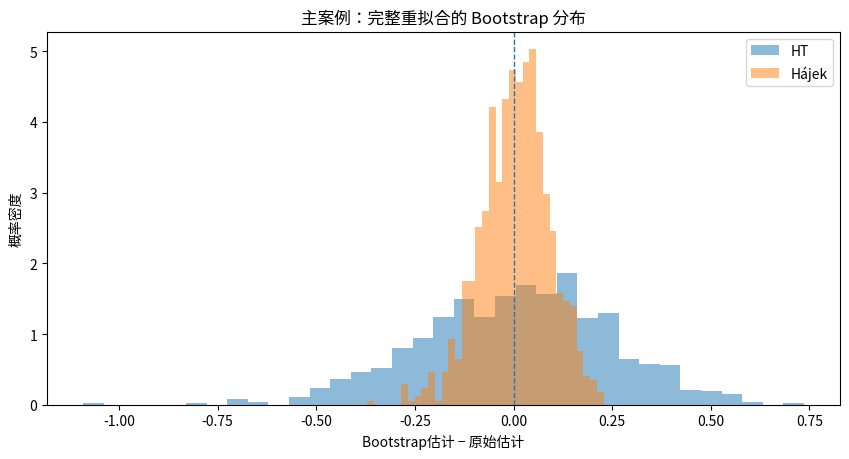

In [11]:
boot_rng = np.random.default_rng(SEED_BOOT)
A = matrices["rich"]
boot_estimates = np.empty((N_BOOT, 2))
for b in range(N_BOOT):
    idx = boot_rng.integers(0, len(y), size=len(y))
    A_b, t_b, y_b = A[idx], t[idx], y[idx]
    fitted_b = fit_logistic(A_b, t_b)
    p_b = np.asarray(fitted_b.predict(A_b))
    estimate_b = ipw_estimate(t_b, y_b, p_b)
    boot_estimates[b] = [estimate_b["HT"], estimate_b["Hájek"]]

# 任何一次计算失败都会报错，不默默删除后把剩余次数写作完整 Bootstrap。
boot_se = boot_estimates.std(axis=0, ddof=1)
point = np.array([base["HT"], base["Hájek"]])
boot_table = pd.DataFrame({"估计": point, "Bootstrap_SE": boot_se,
                           "95%下限": point-Z_CRIT*boot_se,
                           "95%上限": point+Z_CRIT*boot_se}, index=["HT", "Hájek"])
display(boot_table.round(4))
print(f"完成 {len(boot_estimates)} 次整行重抽样；每次重新拟合评分。")

fig, ax = plt.subplots(figsize=(8.6, 4.7))
for j, method in enumerate(["HT", "Hájek"]):
    ax.hist(boot_estimates[:, j]-point[j], bins=35, density=True, alpha=0.5, label=method)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set(xlabel="Bootstrap估计 − 原始估计", ylabel="概率密度", title="主案例：完整重拟合的 Bootstrap 分布")
ax.legend()
fig.tight_layout()
plt.show()

## 进一步分析：重叠变差以后

### 1. 不改处理效应，只改处理分配

前面的 Bootstrap 标准误，HT 约为 0.239，Hájek 约为 0.087。这个例子里归一化明显缩小了波动；它不是所有数据下的优劣定理。接着把比较对象变少，看看归一化还能解决多少问题。

前面的模型有多个变量。为了单独看清重叠，这里换成一个可以直接计算目标的教学例子：

$$
\begin{aligned}
X&\sim\operatorname{Uniform}(-2,2),\qquad e_\kappa(X)=\operatorname{expit}(\kappa X),\\
T\mid X&\sim\operatorname{Bernoulli}\{e_\kappa(X)\},\\
Y(0)&=5+2X+X^2+\varepsilon,\qquad Y(1)=Y(0)+1+X^2,\quad\varepsilon\sim N(0,1).
\end{aligned}
$$

各随机项独立，总体效应始终是 $\tau=1+E[X^2]=7/3$。$\kappa$ 越大，正值 $X$ 越容易接受处理，负值 $X$ 越容易进入对照。因为 $X$ 有界，每个有限 $\kappa$ 下概率仍严格处于 0 与 1 之间；但这不意味着有限样本中的比较就足够稳定。

这对应原书对普通重叠 $0<e(X)<1$ 与远离端点的严格重叠的区分。下面改变的是信息分配，不是总体组成或处理作用。[1，第 11.2.3、20.1 节]

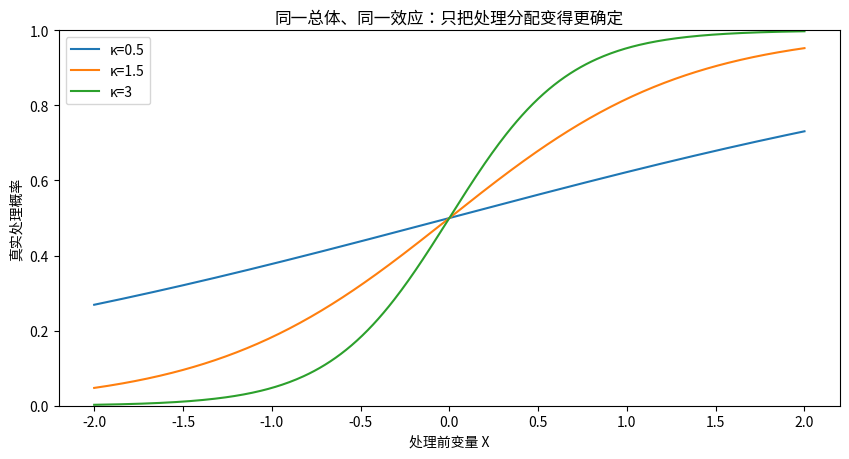

,原始人数,权重和,权重和/n,最大权重,ESS,最大组内份额
组,,,,,,
0,718,1421.8037,0.9479,111.2242,68.5338,0.0782
1,782,1884.2195,1.2561,331.4614,17.7811,0.1759


In [12]:
def make_overlap_data(n: int, strength: float, seed: int):
    if isinstance(n, bool) or not isinstance(n, (int, np.integer)) or n < 20:
        raise ValueError("n 必须是至少为 20 的整数。")
    if not np.isfinite(strength) or strength < 0:
        raise ValueError("strength 必须是有限非负数。")
    rng = np.random.default_rng(seed)
    x = rng.uniform(-2, 2, n)
    p = expit(strength*x)
    t_local = rng.binomial(1, p)
    tau = 1+x**2
    y0 = 5+2*x+x**2+rng.normal(0, 1, n)
    y_local = y0+t_local*tau
    return pd.DataFrame({"X": x, "T": t_local}), y_local, {
        "propensity": p, "tau": tau, "population_ate": 7/3,
    }


x_grid = np.linspace(-2, 2, 401)
fig, ax = plt.subplots(figsize=(8.6, 4.7))
for strength in STRENGTHS:
    ax.plot(x_grid, expit(strength*x_grid), label=f"κ={strength:g}")
ax.set(xlabel="处理前变量 X", ylabel="真实处理概率", ylim=(0, 1),
       title="同一总体、同一效应：只把处理分配变得更确定")
ax.legend()
fig.tight_layout()
plt.show()

weak_design, weak_y, weak_truth = make_overlap_data(N_OVERLAP, STRENGTHS[-1], SEED_OVERLAP)
weak_t = weak_design["T"].to_numpy()
weak_A = np.column_stack([np.ones(N_OVERLAP), weak_design["X"].to_numpy()])
weak_fit = fit_logistic(weak_A, weak_t)
weak_p = np.asarray(weak_fit.predict(weak_A))
display(weight_diagnostics(weak_t, weak_p).round(4))

### 2. 一张分布图，看看权重集中在谁身上

这份样本有 782 位接受者，但处理组 ESS 只有约 17.8，最大的一个权重占该组总权重约 17.6%。权重和约为 1884，显然不能按“1884 位独立接受者”来理解。

把这份低重叠数据中每组的权重从大到小排列。横坐标是组内累积人数比例，纵坐标是这些人占据的累积权重比例。等权时落在对角线上；曲线一开始就快速上升，说明少数人影响很大。这也是本篇增加的诊断图，不是新的效应估计器。

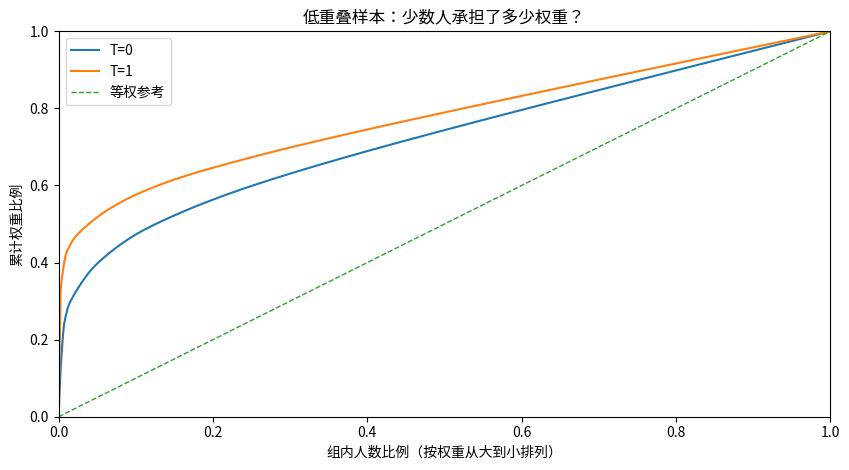

In [13]:
weak_w1, weak_w0 = ipw_weights(weak_t, weak_p)
fig, ax = plt.subplots(figsize=(8.6, 4.8))
for group, w_group in [(0, weak_w0[weak_t == 0]), (1, weak_w1[weak_t == 1])]:
    sorted_w = np.sort(w_group)[::-1]
    fraction = np.arange(1, len(sorted_w)+1)/len(sorted_w)
    cumulative = np.cumsum(sorted_w)/sorted_w.sum()
    ax.plot(np.r_[0, fraction], np.r_[0, cumulative], label=f"T={group}")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="等权参考")
ax.set(xlabel="组内人数比例（按权重从大到小排列）", ylabel="累计权重比例",
       xlim=(0, 1), ylim=(0, 1), title="低重叠样本：少数人承担了多少权重？")
ax.legend()
fig.tight_layout()
plt.show()

### 3. 重新生成 500 份数据

对三个 $\kappa$，各重新生成 500 份研究。每次用 `T ~ X` 重新估计评分，比较 HT 与 Hájek；再用真实评分重复计算，分开观察“评分估计”与“分配本来就接近确定”的影响。

报告 Bias、经验 SD、RMSE 和模拟平均值的 MCSE，并记录两组 ESS 中较小者。经验 SD 是不同研究的估计会有多大变化，不是单份研究里软件给出的标准误。所有方案保持相同的总体目标 $7/3$。

In [14]:
repeat_rng = np.random.default_rng(SEED_REPEAT)
repeat_rows = []
# 留下 κ=3 的原始模拟，后面在完全相同的数据上比较截断与修剪。
weak_replicates = []
for strength in STRENGTHS:
    for repetition in range(N_REPEATS):
        seed = int(repeat_rng.integers(0, 2**32-1))
        data_r, y_r, truth_r = make_overlap_data(N_OVERLAP, strength, seed)
        x_r, t_r = data_r["X"].to_numpy(), data_r["T"].to_numpy()
        A_r = np.column_stack([np.ones(len(x_r)), x_r])
        fitted_r = fit_logistic(A_r, t_r)
        score_options = {"估计评分": np.asarray(fitted_r.predict(A_r)),
                         "真实评分": truth_r["propensity"]}
        for label, p_r in score_options.items():
            result = ipw_estimate(t_r, y_r, p_r)
            rw1, rw0 = ipw_weights(t_r, p_r)
            minimum_ess = min(effective_sample_size(rw1), effective_sample_size(rw0))
            for method in ["HT", "Hájek"]:
                repeat_rows.append({"κ": strength, "评分": label, "方法": method,
                                    "重复": repetition, "估计": result[method], "较小组ESS": minimum_ess})
        if strength == STRENGTHS[-1]:
            weak_replicates.append((x_r, t_r, y_r, truth_r["propensity"]))
repeat_results = pd.DataFrame(repeat_rows)

summary_rows = []
for (strength, score_label, method), part in repeat_results.groupby(["κ", "评分", "方法"], sort=False):
    values = part["估计"].to_numpy()
    error = values-7/3
    summary_rows.append({"κ": strength, "评分": score_label, "方法": method,
                         "次数": len(values), "Bias": error.mean(), "SD": values.std(ddof=1),
                         "RMSE": np.sqrt(np.mean(error**2)), "MCSE": values.std(ddof=1)/np.sqrt(len(values)),
                         "较小组ESS中位数": part["较小组ESS"].median()})
repeat_summary = pd.DataFrame(summary_rows).set_index(["κ", "评分", "方法"])
display(repeat_summary.round(4))
assert len(repeat_results) == len(STRENGTHS)*N_REPEATS*2*2

次数    Bias      SD    RMSE    MCSE  较小组ESS中位数
κ   评分   方法                                                   
0.5 估计评分 HT     500 -0.0094  0.1384  0.1386  0.0062   673.5975
         Hájek  500 -0.0078  0.1136  0.1137  0.0051   673.5975
    真实评分 HT     500 -0.0204  0.4432  0.4432  0.0198   677.2021
         Hájek  500 -0.0069  0.1701  0.1701  0.0076   677.2021
1.5 估计评分 HT     500 -0.0418  0.4675  0.4689  0.0209   326.0685
         Hájek  500 -0.0146  0.1974  0.1977  0.0088   326.0685
    真实评分 HT     500  0.0003  0.6779  0.6772  0.0303   331.9445
         Hájek  500 -0.0046  0.2606  0.2604  0.0117   331.9445
3.0 估计评分 HT     500  0.0706  2.1602  2.1592  0.0966    42.3477
         Hájek  500  0.1090  0.7009  0.7086  0.0313    42.3477
    真实评分 HT     500  0.1206  2.2394  2.2404  0.1001    40.0292
         Hájek  500  0.1084  0.7546  0.7617  0.0337    40.0292

估计评分下，较小组 ESS 的中位数从约 674 降至 42；Hájek 的 RMSE 从约 0.114 增至 0.709，HT 增长得更多。真实评分下也出现了同样的恶化。

这 500 次中，真实评分 HT 的平均偏差不是精确的零；在 κ=3 时约为 0.121，而模拟均值的 MCSE 约为 0.100。这个数还带有明显的 Monte Carlo 波动，不能当成对其期望恒等式的反例。Hájek 作为比值估计，则还可能有有限样本偏差。

下面用对数纵轴展示 RMSE，所有极端结果都保留在汇总中，没有为了让曲线好看删除重复。Hájek 的归一化可以改变波动，但不能让实际缺少比较对象的区域突然增加信息；真实评分也没有这个能力。

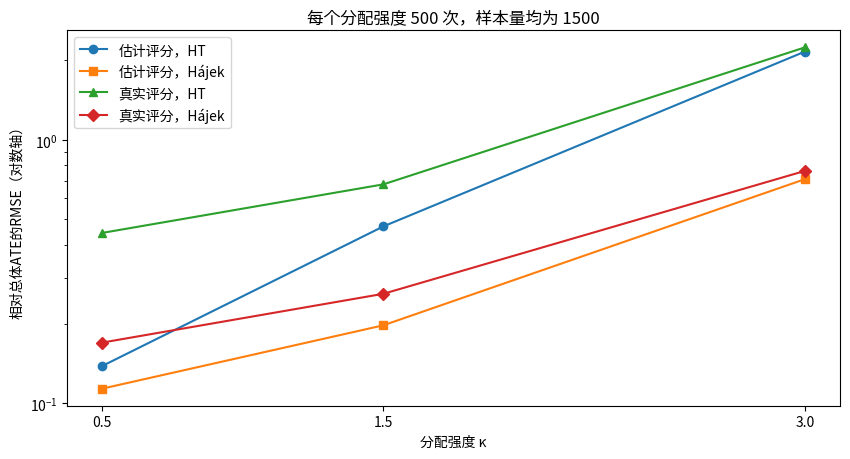

In [15]:
fig, ax = plt.subplots(figsize=(8.6, 4.7))
for (score_label, method), marker in zip(
    [("估计评分", "HT"), ("估计评分", "Hájek"), ("真实评分", "HT"), ("真实评分", "Hájek")],
    ["o", "s", "^", "D"],
):
    part = repeat_summary.xs((score_label, method), level=("评分", "方法")).reindex(STRENGTHS)
    ax.plot(STRENGTHS, part["RMSE"], marker=marker, label=f"{score_label}，{method}")
ax.set(xlabel="分配强度 κ", ylabel="相对总体ATE的RMSE（对数轴）", yscale="log",
       title=f"每个分配强度 {N_REPEATS} 次，样本量均为 {N_OVERLAP}")
ax.set_xticks(STRENGTHS)
ax.legend()
fig.tight_layout()
plt.show()

### 4. 截断评分与修剪样本，不是同一个操作

原书给出两种处理低重叠的办法：将评分限制在区间内，或删除区间外的样本。本篇沿用它的术语，截断（truncation）专指

$$
q_a(X)=\max\{a,\min(\widehat e(X),1-a)\},
$$

然后用 $q_a$ 计算权重，所有人仍在数据中。修剪（trimming）则只保留 $a\le\widehat e(X)\le1-a$ 的人，对保留者仍使用原来的评分。[1，第 11.2.3 节]

评分截断会限制极端权重，但不等于“只把超过某个上限的权重压低”：例如处理者原评分大于 $1-a$ 时，截断还会略微提高他的较小权重。下面不混用这两种定义。

对同一份低重叠数据，预先比较 $a=0.05,0.10$。修剪后报告人数、ESS 和效应；不能只挑一个最接近期待效应的阈值。这里先使用估计评分，阈值和模型均不依结局而选择。

In [16]:
handling_rows = []
for a in [0.0, 0.05, 0.10]:
    modes = ["不处理"] if a == 0 else ["截断评分", "修剪样本"]
    for mode in modes:
        if mode == "修剪样本":
            keep = (weak_p >= a) & (weak_p <= 1-a)
            p_used = weak_p[keep]
        else:
            keep = np.ones(len(weak_t), dtype=bool)
            p_used = weak_p if mode == "不处理" else np.clip(weak_p, a, 1-a)
        z_used, y_used = weak_t[keep], weak_y[keep]
        result = ipw_estimate(z_used, y_used, p_used)
        diag = weight_diagnostics(z_used, p_used)
        handling_rows.append({"方案": mode, "a": a, "保留人数": keep.sum(),
                              "处理人数": int(z_used.sum()), "对照人数": int((1-z_used).sum()),
                              "最大权重": diag["最大权重"].max(), "ESS0": diag.loc[0, "ESS"],
                              "ESS1": diag.loc[1, "ESS"], "HT": result["HT"], "Hájek": result["Hájek"]})
handling_table = pd.DataFrame(handling_rows).set_index(["方案", "a"])
display(handling_table.round(4))

,,保留人数,处理人数,对照人数,最大权重,ESS0,ESS1,HT,Hájek
方案,a,,,,,,,,
不处理,0.00,1500,782,718,331.4614,68.5338,17.7811,5.2357,2.6685
截断评分,0.05,1500,782,718,20.0000,265.1430,287.7725,3.2623,3.6633
修剪样本,0.05,720,371,349,17.5228,185.8910,214.4300,1.2670,1.3704
截断评分,0.10,1500,782,718,10.0000,408.4057,449.5724,3.4697,4.0766
修剪样本,0.10,547,275,272,8.9852,187.7819,188.8505,0.9900,1.0543


表里的 Hájek 结果不能不加区分地都写成“全体 ATE”。修剪改变了人群；截断虽然没有删人，却改变了加权关系，也不保证仍正确估计原来的 ATE。[1，第 20.1.1 节；关于截断的偏差，见下面的直接计算]

### 5. 修剪以后，究竟在估计谁？

先暂时假设真实评分已知，以便把目标变化单独算清楚。对于这个一维例子，

$$
a\le e_\kappa(X)\le1-a
\quad\Longleftrightarrow\quad
|X|\le b_a,\qquad
b_a=\min\!\left\{2,\frac{\log((1-a)/a)}{\kappa}\right\}.
$$

保留区域中的 $X$ 仍为均匀分布，所以新的因果目标为

$$
\tau_{\mathrm{trim}}(a)
=E[1+X^2\mid |X|\le b_a]=1+\frac{b_a^2}{3}.
$$

例如 $\kappa=3,a=0.1$ 时，修剪目标约为 1.179，而全体 ATE 是 2.333。这是目标本身的差别，不是估计器“低估了 1.15”。这段解析计算是本篇为说明原书“修剪改变估计目标”而新增的教学推导。

如果使用估计评分，保留集合也会随样本变化。前面的实用表因此不声称删样本后的某个数恰好对应已知的 1.179；这里用真实评分只为分离这两层问题。

截断又不同。即使真实评分已知，用 $q_a=\operatorname{clip}(e,a,1-a)$ 代替它，Hájek 在总体中的比值为

$$
\frac{E[e(X)\mu_1(X)/q_a(X)]}{E[e(X)/q_a(X)]}
-\frac{E[(1-e(X))\mu_0(X)/(1-q_a(X))]}{E[(1-e(X))/(1-q_a(X))]}.
$$

两项通常平均在不同的有效协变量分布上，因此一般不能直接解释为某一个共同人群的平均因果差值。下面对已写明的生成机制做数值积分，不把这个极限误叫作“截断后的真实 ATE”。

In [17]:
def trimmed_target(strength: float, a: float):
    if not np.isfinite(strength) or strength <= 0 or not np.isfinite(a) or not 0 <= a < 0.5:
        raise ValueError("要求 strength>0，且 0<=a<0.5。")
    bound = 2.0 if a == 0 else min(2.0, np.log((1-a)/a)/strength)
    return {"保留X上界": bound, "总体保留比例": bound/2, "修剪人群ATE": 1+bound**2/3}


# 中点积分：在 Uniform(-2,2) 下，网格平均近似总体期望。
integration_n = 200000
integration_x = -2+(np.arange(integration_n)+0.5)*4/integration_n
integration_e = expit(STRENGTHS[-1]*integration_x)
integration_mu0 = 5+2*integration_x+integration_x**2
integration_mu1 = integration_mu0+1+integration_x**2
limit_rows = []
for a in sorted({0.0, 0.01, 0.05, 0.10, 0.20, TRIM_ALPHA}):
    q = integration_e if a == 0 else np.clip(integration_e, a, 1-a)
    r1, r0 = integration_e/q, (1-integration_e)/(1-q)
    clipped_limit = (np.average(integration_mu1, weights=r1)
                     - np.average(integration_mu0, weights=r0))
    limit_rows.append({"a": a, "全体ATE": 7/3, **trimmed_target(STRENGTHS[-1], a),
                       "截断Hájek总体极限（非ATE）": clipped_limit})
limit_table = pd.DataFrame(limit_rows).set_index("a")
display(limit_table.round(5))
np.testing.assert_allclose(limit_table.loc[0, "截断Hájek总体极限（非ATE）"], 7/3, atol=1e-8)

,全体ATE,保留X上界,总体保留比例,修剪人群ATE,截断Hájek总体极限（非ATE）
a,,,,,
0.00,2.33333,2.00000,1.00000,2.33333,2.33333
0.01,2.33333,1.53171,0.76585,1.78204,2.64024
0.05,2.33333,0.98148,0.49074,1.32110,3.47496
0.10,2.33333,0.73241,0.36620,1.17881,4.00173
0.20,2.33333,0.46210,0.23105,1.07118,4.70175


### 6. 在同一批模拟上，区分目标变化与估计误差

取刚才 $\kappa=3$ 的 500 份数据，固定 $a=0.1$，分别用真实评分计算：不处理、截断评分、修剪样本。这里不再拟合评分；目的是看清楚三种操作本身的后果，不是建议实际研究“使用真实评分”。

表中分别列出总体极限、相对极限的偏差，以及相对全体 ATE 的差距。修剪方法的误差应相对修剪人群 ATE 计算；截断方法的数值极限则不冒充因果目标。图中每组减去自己的总体极限，才适合比较估计波动。

,总体极限,平均估计,相对极限Bias,相对全体ATE差距,SD,MCSE,相对极限RMSE
方案,,,,,,,
不处理,2.33333,2.44176,0.10843,0.10843,0.75465,0.03375,0.76165
截断评分,4.00173,4.00688,0.00515,1.67355,0.21804,0.00975,0.21788
修剪样本,1.17881,1.17309,-0.00572,-1.16025,0.14622,0.00654,0.14618


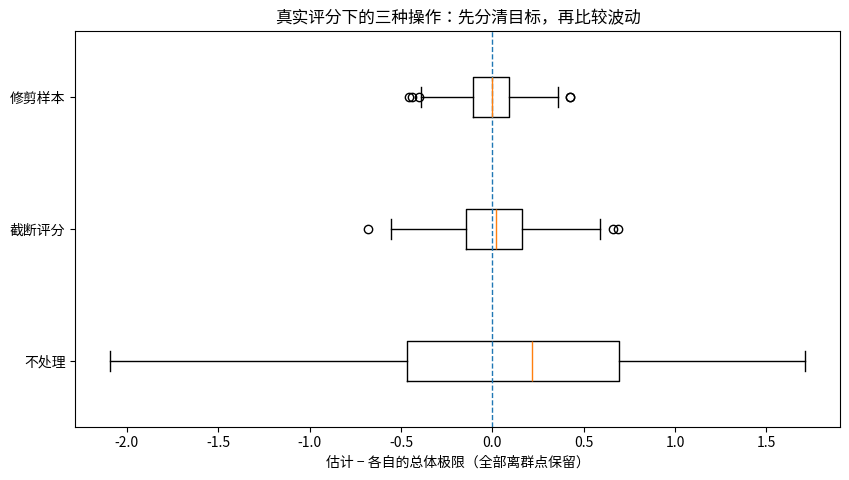

In [18]:
a = TRIM_ALPHA
trim_limit = trimmed_target(STRENGTHS[-1], a)["修剪人群ATE"]
clip_limit = float(limit_table.loc[a, "截断Hájek总体极限（非ATE）"])
comparison_limits = {"不处理": 7/3, "截断评分": clip_limit, "修剪样本": trim_limit}
paired_rows = []
for repetition, (x_r, t_r, y_r, p_r) in enumerate(weak_replicates):
    keep = (p_r >= a) & (p_r <= 1-a)
    values = {
        "不处理": ipw_estimate(t_r, y_r, p_r)["Hájek"],
        "截断评分": ipw_estimate(t_r, y_r, np.clip(p_r, a, 1-a))["Hájek"],
        "修剪样本": ipw_estimate(t_r[keep], y_r[keep], p_r[keep])["Hájek"],
    }
    for label, estimate in values.items():
        paired_rows.append({"方案": label, "重复": repetition, "估计": estimate,
                            "自己的总体极限": comparison_limits[label]})
paired_results = pd.DataFrame(paired_rows)
paired_summary_rows = []
for label, part in paired_results.groupby("方案", sort=False):
    values = part["估计"].to_numpy()
    limit = comparison_limits[label]
    paired_summary_rows.append({"方案": label, "总体极限": limit, "平均估计": values.mean(),
                                "相对极限Bias": values.mean()-limit, "相对全体ATE差距": values.mean()-7/3,
                                "SD": values.std(ddof=1), "MCSE": values.std(ddof=1)/np.sqrt(len(values)),
                                "相对极限RMSE": np.sqrt(np.mean((values-limit)**2))})
paired_summary = pd.DataFrame(paired_summary_rows).set_index("方案")
display(paired_summary.round(5))

fig, ax = plt.subplots(figsize=(8.6, 4.9))
labels = list(comparison_limits)
errors = [paired_results.loc[paired_results["方案"] == label, "估计"].to_numpy()-comparison_limits[label]
          for label in labels]
ax.boxplot(errors, orientation="horizontal", showfliers=True, tick_labels=labels)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set(xlabel="估计 − 各自的总体极限（全部离群点保留）",
       title="真实评分下的三种操作：先分清目标，再比较波动")
fig.tight_layout()
plt.show()

默认模拟里，截断后的平均估计约为 4.007，接近它的数值极限 4.002，却离全体 ATE 很远。修剪后的平均估计约为 1.173，接近保留人群的 ATE 1.179。两者更稳定，并不表示在回答同一个问题。

修剪以后，尾部的高效应人群不再是目标的一部分。评分截断仍保留这些人，却没有按原来的比例补回两组，因此它的极限又是另一个数。三种方法的标准差即使不同，也不能只按“区间最窄”来选择。

实际分析中，先报告原始重叠、权重集中程度与保留人群，再说明阈值及其理由。若阈值随估计评分而改变，推断还要处理保留集合的估计；本篇没有为这种硬修剪程序给出通用置信区间，也不沿用前面未修剪 IPW 的区间。原书对修剪的理论另外引用了专门研究。[1，第 11.2.3、20.1.1 节]

## 练习

### 1. 稳定化权重真的把极端权重问题消除了吗？

在本篇的二元处理、全体 ATE 场景，给处理权重乘边际处理比例 $\widehat p$，给对照权重乘 $1-\widehat p$，得到：

$$
\mathrm{SW}_i=
T_i\frac{\widehat p}{\widehat e_i}
+(1-T_i)\frac{1-\widehat p}{1-\widehat e_i},\qquad
\widehat p=\frac1n\sum_iT_i.
$$

这是本篇增加的代数练习。先不看代码，判断组内归一化均值、Hájek 差值、每组 ESS 会不会改变。再判断：直接把 SW 代入“加权总和除以 $n$”是否仍是原来的 HT 公式？

参考思路：同一组内乘的是同一个常数。组内加权平均的分子和分母会一起变化；原始 HT 的固定分母 $n$ 却不会跟着变化。稳定化不能凭空提高组内 ESS。

In [19]:
p_marginal = weak_t.mean()
stabilized_w1 = p_marginal*weak_w1
stabilized_w0 = (1-p_marginal)*weak_w0
raw_weak = ipw_estimate(weak_t, weak_y, weak_p)
stabilized_hajek = (np.average(weak_y, weights=stabilized_w1)
                    - np.average(weak_y, weights=stabilized_w0))
# 下面故意保留这种不同的计算，用来说明它不是原来的 HT。
stabilized_fixed_n = (np.dot(stabilized_w1, weak_y)-np.dot(stabilized_w0, weak_y))/len(weak_y)

display(pd.DataFrame({
    "原始IPW": [raw_weak["Hájek"], effective_sample_size(weak_w0), effective_sample_size(weak_w1)],
    "稳定化后组内归一化": [stabilized_hajek, effective_sample_size(stabilized_w0),
                         effective_sample_size(stabilized_w1)],
}, index=["Hájek", "ESS0", "ESS1"]).round(6))
print(f"原始HT：{raw_weak['HT']:.6f}")
print(f"稳定化权重直接除以n（不是原始HT）：{stabilized_fixed_n:.6f}")
np.testing.assert_allclose(stabilized_hajek, raw_weak["Hájek"], atol=1e-12)
np.testing.assert_allclose(effective_sample_size(stabilized_w0), effective_sample_size(weak_w0), atol=1e-10)
np.testing.assert_allclose(effective_sample_size(stabilized_w1), effective_sample_size(weak_w1), atol=1e-10)

,原始IPW,稳定化后组内归一化
Hájek,2.668481,2.668481
ESS0,68.533842,68.533842
ESS1,17.781065,17.781065


原始HT：5.235667
稳定化权重直接除以n（不是原始HT）：2.976643


### 2. 加权回归得到的是 HT，还是 Hájek？

使用 $w_i=w_{1i}+w_{0i}$，拟合只含截距与二元处理的加权最小二乘：

$$
(\widehat\alpha,\widehat\beta)=
\arg\min_{\alpha,\beta}\sum_iw_i(Y_i-\alpha-\beta T_i)^2.
$$

分别对两组看正规方程：截距拟合对照组加权均值，截距加处理系数拟合处理组加权均值，因此 $\widehat\beta=\widehat\tau_{\mathrm{H}}$。这是数值恒等式，不要求结局的条件均值真的是线性的。[1，命题 14.1]

先用平方根权重把设计矩阵与结局同时变换，手写一次最小二乘；再用 statsmodels 核对。这里只比较点估计，不直接采用 WLS 的默认标准误：评分本身也是估计出来的，原书明确指出该默认标准误不能代替整套 IPW 程序的不确定性。[1，第 14.2.1 节]

In [20]:
w_actual = w1+w0
A_wls = np.column_stack([np.ones(len(t)), t])
root_w = np.sqrt(w_actual)
beta_manual, _, rank, _ = np.linalg.lstsq(A_wls*root_w[:, None], y*root_w, rcond=None)
assert rank == 2
wls_result = sm.WLS(y, A_wls, weights=w_actual).fit()

display(pd.Series({"直接计算Hájek": base["Hájek"], "平方根加权后手写最小二乘": beta_manual[1],
                   "statsmodels WLS处理系数": wls_result.params[1],
                   "HT（作为区分）": base["HT"]}, name="点估计").to_frame().round(8))
np.testing.assert_allclose([beta_manual[1], wls_result.params[1]], base["Hájek"], atol=1e-10)

# 另一个边界核对：常数评分下 Hájek 就是两组普通均值差。
constant_est = ipw_estimate(t, y, np.full(len(t), 0.5))
raw_difference = y[t == 1].mean()-y[t == 0].mean()
np.testing.assert_allclose(constant_est["Hájek"], raw_difference, atol=1e-12)
# HT 需要评分取本样本处理比例，才保证这个有限样本恒等式。
empirical_constant_est = ipw_estimate(t, y, np.full(len(t), t.mean()))
np.testing.assert_allclose(empirical_constant_est["HT"], raw_difference, atol=1e-12)
print("核对通过：WLS = Hájek；常数经验评分下 HT = Hájek = 原始均值差。")

,点估计
直接计算Hájek,2.435859
平方根加权后手写最小二乘,2.435859
statsmodels WLS处理系数,2.435859
HT（作为区分）,2.285432


核对通过：WLS = Hájek；常数经验评分下 HT = Hájek = 原始均值差。


## 小结

逆概率加权把处理概率较小却实际接受处理的人、对照概率较小却实际未接受处理的人赋予较大权重。HT 按全体人数作分母，Hájek 分别归一化两组；两者的差别在有限样本中会直接影响结果。

加权后仍要检查协变量平衡、实际权重分布和每组 ESS。权重很集中时，评分模型即使写对了，也不能保证一份样本已经足够稳定。归一化与稳定化都不能补回不存在的比较信息。

评分截断不删人，但会改变加权关系；样本修剪会改变目标人群。报告效应之前，先说清楚估计的是全体、保留人群，还是一个已经不能直接解释为共同人群因果差值的加权对比。下一篇转向匹配，讨论如何为接受处理的人寻找对照。

## 参考资料与本篇改写范围

[1] Peng Ding. *A First Course in Causal Inference*. 上传文件《因果推断.pdf》，arXiv:2305.18793v2，2023-10-03。主要参考第 11.2 节（HT、Hájek、平移性质、评分截断与 Bootstrap），第 11.3 节（协变量平衡），第 20.1.1 节（修剪改变人群与目标）；另用习题 12.1 的部分结论、命题 14.1 与附录 A.6。主要正文页 158–164、268，对应该附件 PDF 页 184–190、294。

[2] Victor Chernozhukov, Christian Hansen, Nathan Kallus, Martin Spindler, Vasilis Syrgkanis. *Applied Causal Inference Powered by ML and AI*. 上传文件《CausalML_book_2022.pdf》，扉页版本为 0.1.2，2026-05-03。第 5.3 节、定理 5.3.1：通过处理概率加权识别潜在均值及 HT 变换。正文页 140–142，对应 PDF 页 150–152。该书以 $D,p(X)$ 表示处理和评分，这里沿用前几篇的 $T,e(X)$。

[3] statsmodels 官方接口文档：二项 GLM 用于拟合处理概率；WLS 仅作点估计核对。实现时显式加入截距与 `Binomial` 分布。接口说明：`https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.html`；`https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.WLS.html`。实际执行版本见开头的环境输出，不要求安装网页所列的最新版本。

计算范围说明：本篇没有复现原书 NHANES 的实证结果。三层汇总表、继承的三变量模拟和一维重叠模拟都是教学构造。ESS、SMD 固定分母、权重集中曲线、稳定化权重不变性、修剪目标与截断总体极限均为围绕原书方法新增的计算与推导，不冒充书中的原始定理或实验。对照常数评分时，区分第二本书的总体加权恒等式与本篇有限样本中 HT、Hájek 的不同分母。